# 05 - Modelling 
## Objectives
The objective of this notebook is to predict the next-hour French day-ahead electricity price using market fundamentals and renewable generation features.

Because electricity prices exhibit strong temporal dependence, seasonality, and extreme scarcity events, the modelling approach emphasizes:

- Time-aware validation
- Leakage prevention
- Robust handling of non-linear relationships
- Separate evaluation of tail-price behavior 

## Data
Loaded from "data/processed/df_alls_cleaned.parquet" (produced by "01_data_processing.ipynb")

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import missingno as msno
import pyarrow

sys.path.append("../src")
import style 
style.apply_style()

import features
import data_split
import train
import evaluate
import plots

pd.set_option("display.max_columns", 50)

df_alls = pd.read_parquet("../data/processed/df_alls_cleaned.parquet")

## Target

In [2]:
col_modelling = [
    "Day-ahead Price (EUR/MWh)",
    "Actual Total Load (MW)_load",
    "Day-ahead Total Load Forecast (MW)_load",
    "Day-ahead (MW)_wind_onshore",
    "Day-ahead (MW)_solar"
]

df = df_alls[col_modelling].copy()
df["Actual Total Load (MW)_load"] = df["Actual Total Load (MW)_load"].interpolate()
df["target_price"] = df["Day-ahead Price (EUR/MWh)"].shift(-1)

## Feature engineering
### Calendar features

In [3]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

In [4]:
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

### Lag features

df["price_lag_1"] = df["Day-ahead Price (EUR/MWh)"].shift(1)
df["price_lag_24"] = df["Day-ahead Price (EUR/MWh)"].shift(24)
df["price_lag168"] = df["Day-ahead Price (EUR/MWh)"].shift(168)

In [5]:
df = features.add_price_features(df, lags = [1, 24, 168], rolling_windows = [24, 72])

### Rolling statistics

df["price_roll_mean_24"] = (
    df["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()
)

df["price_roll_std_24"] = (
    df["Day-ahead Price (EUR/MWh)"].rolling(window = 24).std()
)

df.isna().sum()

In [6]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78743 entries, 2016-01-08 00:00:00+01:00 to 2024-12-31 22:00:00+01:00
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Day-ahead Price (EUR/MWh)                78743 non-null  float64
 1   Actual Total Load (MW)_load              78743 non-null  float64
 2   Day-ahead Total Load Forecast (MW)_load  78743 non-null  float64
 3   Day-ahead (MW)_wind_onshore              78743 non-null  float64
 4   Day-ahead (MW)_solar                     78743 non-null  float64
 5   target_price                             78743 non-null  float64
 6   hour                                     78743 non-null  int32  
 7   dayofweek                                78743 non-null  int32  
 8   month                                    78743 non-null  int32  
 9   is_weekend                               78743 non-null  int64  
 10 

### Renewable features

In [7]:
df["renewable_ratio"] = (
    df["Day-ahead (MW)_solar"] +  
    df["Day-ahead (MW)_wind_onshore"] 
)/df["Day-ahead Total Load Forecast (MW)_load"]

### Scarcity / stress indicators

In [8]:
df["residual_load"] = (df["Day-ahead Total Load Forecast (MW)_load"] - (
    df["Day-ahead (MW)_solar"] 
    + df["Day-ahead (MW)_wind_onshore"]
    ))

df["high_residual_load"] = (
    df["residual_load"] > df["residual_load"].quantile(0.05)
).astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78743 entries, 2016-01-08 00:00:00+01:00 to 2024-12-31 22:00:00+01:00
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Day-ahead Price (EUR/MWh)                78743 non-null  float64
 1   Actual Total Load (MW)_load              78743 non-null  float64
 2   Day-ahead Total Load Forecast (MW)_load  78743 non-null  float64
 3   Day-ahead (MW)_wind_onshore              78743 non-null  float64
 4   Day-ahead (MW)_solar                     78743 non-null  float64
 5   target_price                             78743 non-null  float64
 6   hour                                     78743 non-null  int32  
 7   dayofweek                                78743 non-null  int32  
 8   month                                    78743 non-null  int32  
 9   is_weekend                               78743 non-null  int64  
 10 

In [10]:
features_col = [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofweek",
    "is_weekend",

    "price_lag_1",
    "price_lag_24",
    "price_lag_168",
    "price_roll_mean_24",
    "price_roll_std_24",
    "price_roll_max_24",
    "price_roll_min_24",
    "price_roll_mean_72",
    "price_roll_std_72",
    "price_roll_max_72",
    "price_roll_min_72",

    "Actual Total Load (MW)_load",
    "Day-ahead Total Load Forecast (MW)_load",

    "Day-ahead (MW)_wind_onshore",
    "Day-ahead (MW)_solar",

    "renewable_ratio",
    "residual_load",
    "high_residual_load"
]

## Train test split
Since 2022 introduced an unprecedented market volatility due to the energy crisis in Europe, we will split the dataset accordingly to ensure model robustness under regime shifts. 

The training set will be 2016-2020, validation set will be 2021. 2022 will be used for stress test. 2023-2024 will be used for recovery and generalization test.

In [12]:
(X_train,
y_train,
X_val,
y_val,
X_test,
y_test,
X_recovery,
y_recovery
) = data_split.split_data(df, features_col)

## Gradient boosting modelling

In [13]:
from lightgbm import LGBMRegressor, plot_importance
from sklearn.metrics import mean_absolute_error, root_mean_squared_error 


In [14]:
model = LGBMRegressor(
    n_estimators = 300, 
    learning_rate = 0.05,
    max_depth = 6,
    num_leaves = 31,
    random_state = 42
)

In [15]:
train.train_regression(model, X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
y_val_pred = model.predict(X_val)

In [17]:
evaluate.evaluate_regression(y_val, y_val_pred)

{'mae': 39.391932873002915, 'rmse': 75.77857402988147}

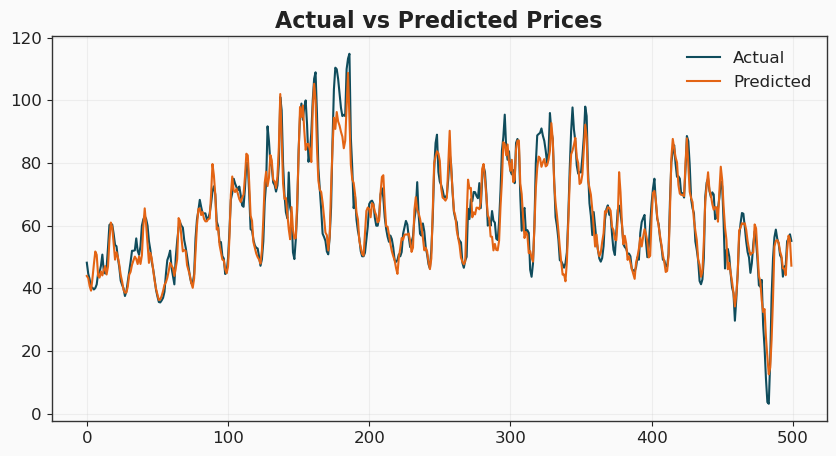

In [18]:
plots.plot_actual_pred_diff(y_val, y_val_pred)

The model has nicely captured the cyclic features of the actual price, as well as the overall trend. The extreme spikes are less accurately predicted. 

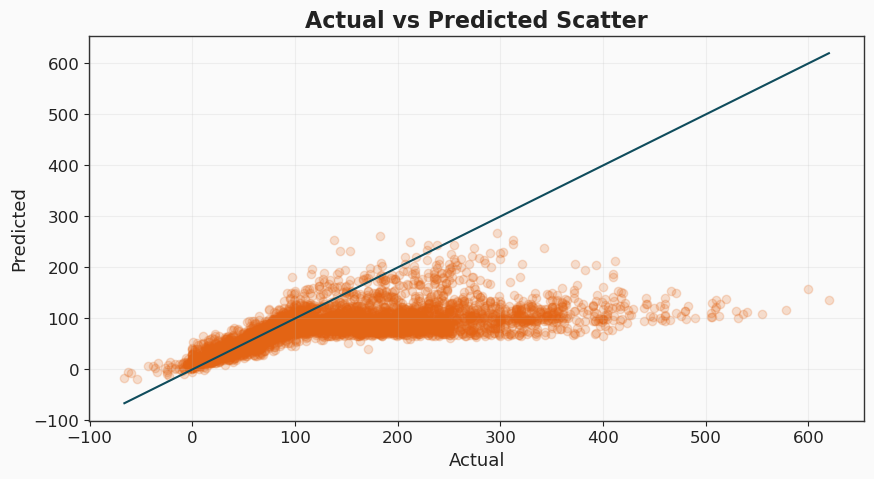

In [19]:
plots.plot_actual_pred_scatter(y_val, y_val_pred)

The scatter plot reveals that the model can handle low range price prediction very well, but lose focus when the actual price reaches 100 EUR/MWh.

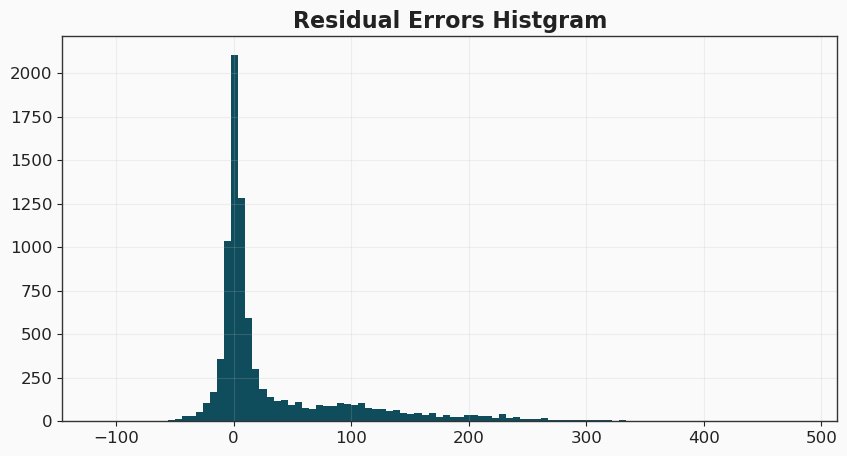

In [20]:
plots.plot_residual(y_val, y_val_pred)

The long positive tail in the histgram of residual errors for the validation set reveals that the model underpredicts extreme incidents. Based on these feedbacks, we will continue to improve the model by introducing tail-performance analysis.
### Tail-performance analysis

In [23]:
tail_threshold = y_val.quantile(0.95)
tail_mask = y_val >= tail_threshold

In [24]:
mae_tail_val = mean_absolute_error(
    y_val[tail_mask],
    y_val_pred[tail_mask]
)

mae_norm_val = mean_absolute_error(
    y_val[~tail_mask],
    y_val_pred[~tail_mask]
)

print("Validation Set MAE Tail", mae_tail_val, "\n", "Validation Set MAE Norm", mae_norm_val)

Validation Set MAE Tail 244.97021938213206 
 Validation Set MAE Norm 28.572023056732952


The model performs well for 95% of the time, while the 5% extreme cases the model fails to perform.

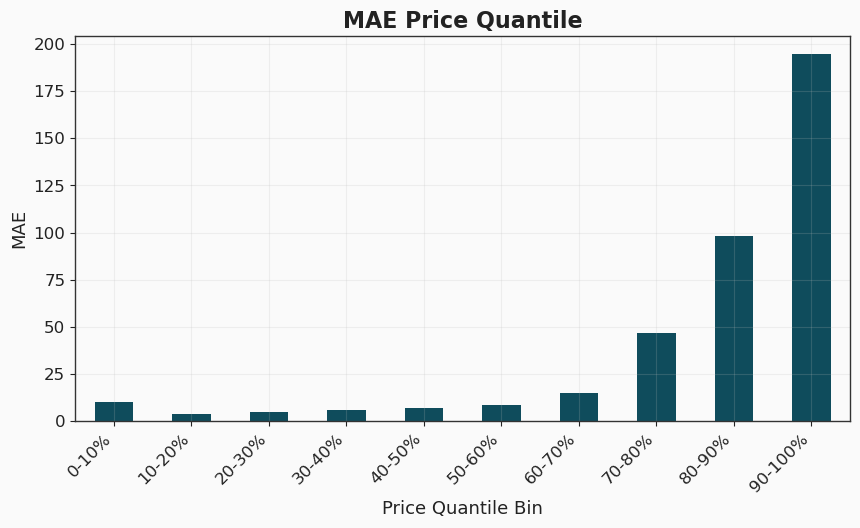

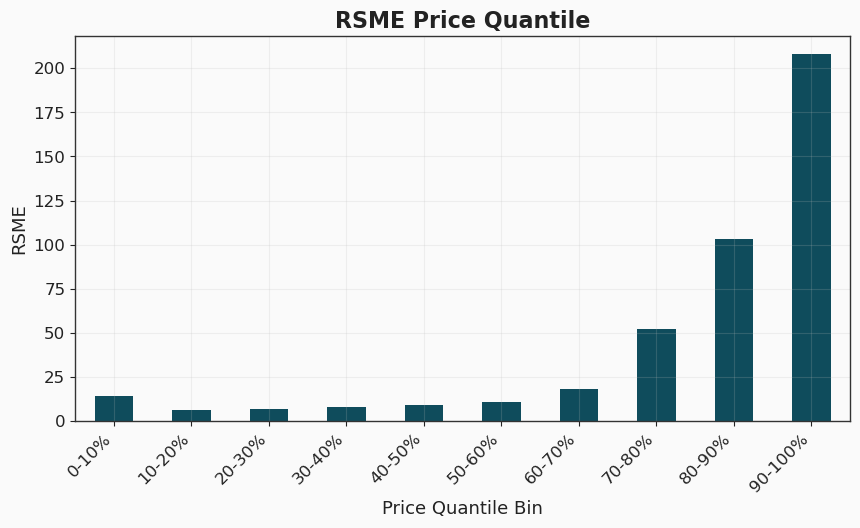

In [21]:
plots.plot_error_by_price_quantile(y_val, y_val_pred)

Model prediction errors increase sharply in the upper price quantiles, indicating that scarcity-driven price regimes remain difficult to model. This behavior is consistent with the steep upper-tail structure observed in the residual load duration curve in notebook 03.

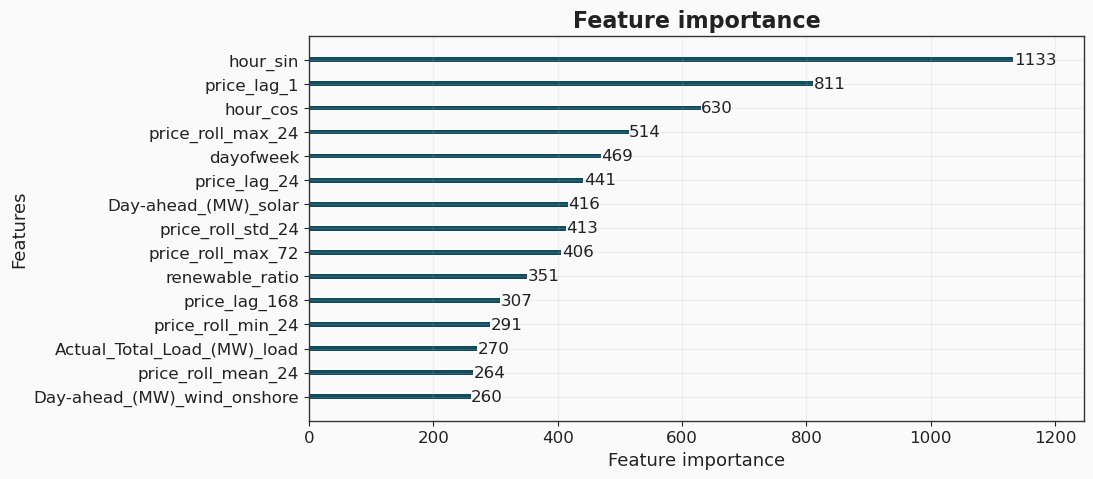

In [22]:
plots.plot_feature_importance(model)

Lightgbm feature importance indicates hour, rolling volatility and price lag are the top features. However, it is important to keep in mind that many other features overlaps with these top features, such as solar generations.

## Time-series cross-validation

In [25]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits = 5)

## Baseline models
### Persistence model

In [26]:
pred_naive = X_test["price_lag_1"]

### Previous day same hour

In [27]:
pred_24h = X_test["price_lag_24"]

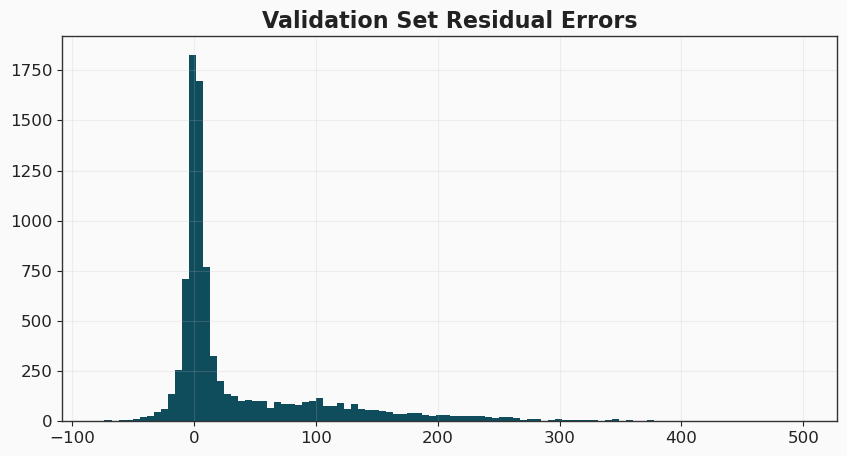

In [36]:
residual_val_set = y_val - y_val_pred
plt.figure()
plt.hist(residual_val_set, bins = 100, color = style.COLORS["primary"])
plt.title("Validation Set Residual Errors")
plt.show()

In [91]:
val_quantiles = pd.qcut(y_val, 10, precision = 2, labels = [
    "0-10%", "10-20%", "20-30%", "30-40%", "40-50%", 
    "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"
])
val_quantiles.value_counts()

target_price
0-10%      877
10-20%     876
30-40%     876
40-50%     876
50-60%     876
60-70%     876
70-80%     876
80-90%     876
90-100%    876
20-30%     875
Name: count, dtype: int64

In [90]:
df_val = pd.DataFrame({
    "actual": y_val,
    "predicted": y_val_pred,
    "quantile_bin": val_quantiles
}
)
df_val["abs_error"] = (np.abs(df_val["actual"] - df_val["predicted"]))
df_val

,actual,predicted,quantile_bin,abs_error
timestamp,,,,
2021-01-01 00:00:00+01:00,48.19,44.604858,10-20%,3.585142
2021-01-01 01:00:00+01:00,44.68,43.846578,10-20%,0.833422
2021-01-01 02:00:00+01:00,42.92,41.171069,10-20%,1.748931
2021-01-01 03:00:00+01:00,40.39,39.909958,0-10%,0.480042
2021-01-01 04:00:00+01:00,40.20,43.359697,0-10%,3.159697
...,...,...,...,...
2021-12-31 19:00:00+01:00,157.92,101.801945,70-80%,56.118055
2021-12-31 20:00:00+01:00,175.12,56.911612,80-90%,118.208388
2021-12-31 21:00:00+01:00,140.38,62.960606,70-80%,77.419394


In [84]:
mae_val_by_bin = (df_val.groupby("quantile_bin", observed = False)["abs_error"].mean())
mae_val_by_bin

quantile_bin
0-10%        9.958833
10-20%       4.032734
20-30%       5.005909
30-40%       5.875819
40-50%       6.465224
50-60%       8.189385
60-70%      15.525604
70-80%      53.789638
80-90%     104.862455
90-100%    196.162433
Name: abs_error, dtype: float64

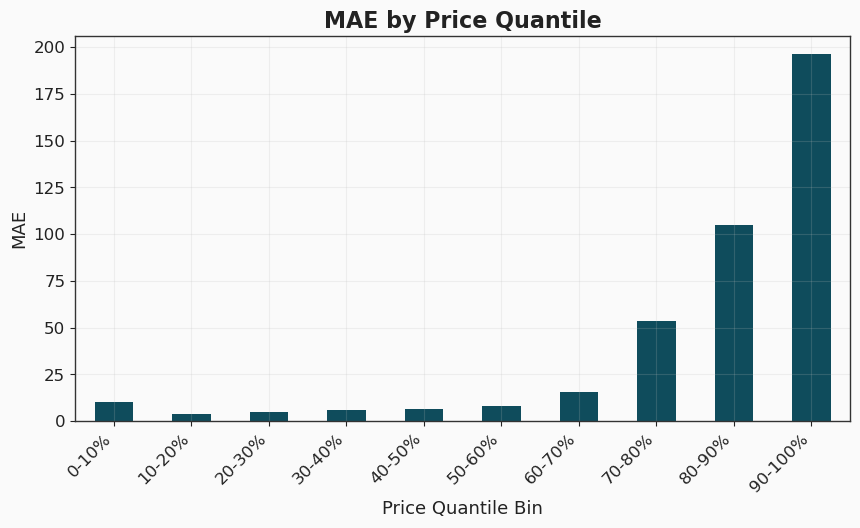

In [85]:
mae_val_by_bin.plot(kind = "bar", color = style.COLORS["primary"])
plt.xlabel("Price Quantile Bin")
plt.ylabel("MAE")
plt.title("MAE by Price Quantile")
plt.xticks(rotation = 45, ha = "right")
plt.show()

In [92]:
rmse_by_bin = (
    df_val.assign(
        squared_error = lambda x: (x["actual"] - x["predicted"])**2
    )
    .groupby("quantile_bin", observed = False)["squared_error"]
    .mean()
    .pipe(np.sqrt)
)
rmse_by_bin

quantile_bin
0-10%       14.243524
10-20%       5.903434
20-30%       7.200901
30-40%       8.711677
40-50%       9.265775
50-60%      11.553709
60-70%      19.722171
70-80%      59.733700
80-90%     109.903786
90-100%    209.817879
Name: squared_error, dtype: float64

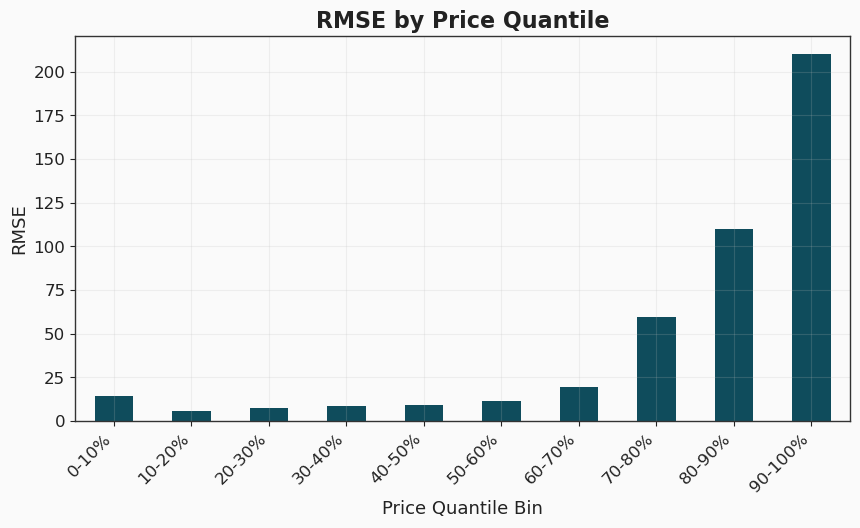

In [95]:
rmse_by_bin.plot(kind = "bar", color = style.COLORS["primary"])
plt.xlabel("Price Quantile Bin")
plt.ylabel("RMSE")
plt.title("RMSE by Price Quantile")
plt.xticks(rotation = 45, ha = "right")
plt.show()

In [18]:
y_val_pred = model.predict(X_val)

NameError: name 'X_val' is not defined

In [ ]:

mae_naive = mean_absolute_error(y_test_pred, pred_naive)
mae_naive

206.44439527403134

In [ ]:
root_mean_squared_error(y_test_pred, pred_naive)

249.02770537252513

In [93]:
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(
    estimator = model,
    cv = tscv
)
clf.fit(X_train, y_train)

TypeError: GridSearchCV.__init__() missing 1 required positional argument: 'param_grid'